In [1]:
!pip install gym==0.22.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 631.1/631.1 kB 25.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for gym: filename=gym-0.22.0-py3-none-any.whl size=708474 sha256=db6597444dbc906470b1488c00f80bf604dd5d38d2e6bc8de4ba5888b1451762
  Stored in directory: /root/.cache/pip/wheels/fd/bd/03/a325acb1df8746ce0573ffdf8730f4e7d32f4aa839a56f1b2f
Successfully built gym
  Attempting uninstall: gym
    Found existing installation: gym 0.25.2
    Uninstalling gym-0.25.2:
      Successfully uninstalled gym-0.25.2


### 2. Q-обучение


Q функция(оценивает текущую стратегию $\pi$):
$$Q^\pi(s,a) = \mathbb{E}_\pi \left[ \sum_{k=0}^\infty \gamma^k r_{t+k} \,\Big|\, s_0 = s, a_0 = a \right]$$

Уравнение Беллмана:
$$Q^\pi(s,a) = \mathbb{E}_{s'\sim\mathcal{P}, r\sim\mathcal{R}} \left[
    r + \gamma Q^\pi(s',\pi(s')) \mid s,a
\right]$$

Уравнение оптимальности Беллмана для значения Q-функции записывается как:
$$Q^*(s, a) = \mathbb{E}\left[ r + \gamma \cdot \max_{a'} Q^*(s', a') \,\middle|\, s, a \right]$$

От сюда получаем алгоритм Q learning где уравнение для итерационного обновления значений Q-функции выглядит следующим образом(добавляется alpha = learning rate):$$Q(s,a)\leftarrow Q(s,a)+\alpha \big (r(s)+\gamma\max_{a'}Q(a',s') - Q(s,a) \big ).$$

Раскроем скобки:
$$Q(s,a)\leftarrow (1 - \alpha) \times Q(s,a)+\alpha \times \big (r(s)+\gamma\max_{a'}Q(a',s')\big ).$$


где $Q_{target} = r(s)+\gamma\max_{a'}Q(a',s')$


In [2]:
!pip install pygame

Для обучения будем использовать среду Taxi-v3. Подробнее про данное окружение можно посмотреть в документации: https://gym.openai.com/envs/Taxi-v3/.

In [3]:
import gym
import numpy as np
import matplotlib.pyplot as plt
import random

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [4]:
env = gym.make("Taxi-v3")
env.reset()
env.render()

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+



In [5]:
def show_progress(rewards_batch, log, reward_range=None, loss_batch=None, log_loss=[]):
    """
    Удобная функция, которая отображает прогресс обучения.
    """

    if reward_range is None:
        reward_range = [-990, +10]
    mean_reward = np.mean(rewards_batch)
    log.append([mean_reward])
    if not (loss_batch is None):
      mean_loss = np.mean(loss_batch)
      log_loss.append([mean_loss])

    clear_output(True)
    plt.figure(figsize=[8, 4])
    ax1 = plt.subplot(1, 2, 1)
    ax1.plot(list(zip(*log))[0], label='Mean rewards')
    ax1.legend(loc=4)
    ax1.grid()

    if not (loss_batch is None):
      ax2 = plt.subplot(1, 2, 2)
      ax2.plot(list(zip(*log_loss))[0], label='Mean loss')
      ax2.legend(loc=4)
      ax2.grid()

    plt.grid()
    plt.grid()
    plt.show()

#### Задание 1

Создайте таблицу из нулей, используя информацию из окружения о количестве состояний и действий

In [6]:
import random
from IPython.display import clear_output

In [8]:
print(env.observation_space.n)

500


In [9]:
print(env.action_space.n)

6


In [10]:
def initialize_q_table(env):
    # подсказка смотрим env.observation_space и env.action_space
    # q_table_ = [state][action]
    ####### Здесь ваш код ########
    rows = env.observation_space.n
    cols = env.action_space.n
    q_table_= np.zeros([rows, cols])
    ##############################
    return q_table_

#### Задание 2

Напишите код для формулы Q-обновления, используя известные: alpha, reward, gamma, next_max, old_value (q_table[state, action])

$$Q(s,a)\leftarrow (1 - \alpha) \times Q(s,a)+\alpha \times \big (r(s)+\gamma\max_{a'}Q(a',s')\big ).$$

In [16]:
# гиперпараметры алгоритма
alpha = 0.2
gamma = 0.7
epsilon = 0.2
episodes_number = 10001

где $Q_{target} = r(s)+\gamma\max_{a'}Q(a',s')$

$$Q(s,a)\leftarrow (1 - \alpha) \times Q(s,a)+\alpha \times \big ( Q таргет).$$

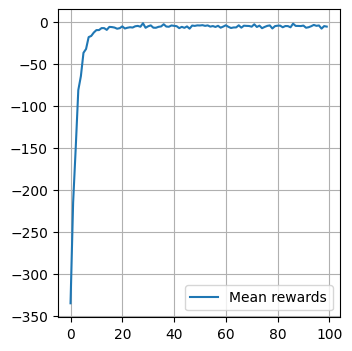

Episode: 10000, Reward: -7


In [17]:
# определяем память, в которой будет храниться Q(s,a)
q_table = initialize_q_table(env)
log = []
rewards_batch = []

for i in range(1, episodes_number):
    state = env.reset()

    episode, reward, episode_reward = 0, 0, 0
    done = False

    while not done:
        # выбираем действие, используя eps-greedy исследование среды
        # с вероятностью epsilon выбираем случайное действие, иначе
        # выполняем действие жадно, согласно текущей Q-таблице
        # action =
        ####### Здесь ваш код ########
        if np.random.random() <= epsilon:
          action = env.action_space.sample()
        else:
          action = np.argmax(q_table[state])

        ##############################

        # выполняем действие в среде
        next_state, reward, done, info = env.step(action)

        # код для Q-обновления
        # Q =
        # Q_target =
        # new_Q =
        ####### Здесь ваш код ########
        Q = q_table[state][action]
        # это взяли награду + дисконт * выбор наилучшего действия в этом состоянии
        Q_target = reward + gamma * np.max(q_table[next_state])
        new_Q = (1- alpha) * Q + alpha * Q_target
        ##############################

        q_table[state][action] = new_Q

        state = next_state
        episode += 1
        episode_reward += reward
    rewards_batch.append(episode_reward)

    if i % 100 == 0:
        show_progress(rewards_batch, log)
        rewards_batch = []
        print(f"Episode: {i}, Reward: {episode_reward}")

### Интерпретация результатов:
Если все сделано правильно, то график должен выйти на плато около 0. А значение вознаграждение будет в диапазоне [-5, 10], за счет случайного выбора начальной позиции такси и пассажира. Попробуйте изменить гиперпараметры и сравните результаты.

## 3. Q learning with NN

В данном пункте мы будем использовать библиотеку pytorch для обучения нейронной сети, хотя можно использовать и любую другую библиотеку.

In [18]:
import gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [20]:
env = gym.make("CartPole-v0").env

env.reset()
n_actions = env.action_space.n
state_dim = env.observation_space.shape[0]

print(n_actions)

env.close()

2


/usr/local/lib/python3.12/dist-packages/gym/envs/registration.py:505: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1` with the environment ID `CartPole-v1`.
  logger.warn(


In [24]:
state_dim

4

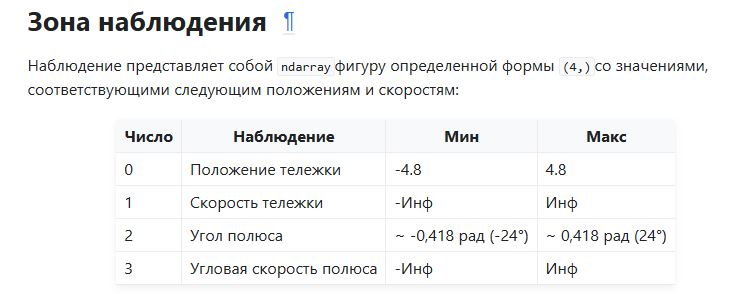

https://gymnasium.farama.org/environments/classic_control/cart_pole/


Так как описание состояния в задаче с маятником представляет собой не "сырые" признаки, а уже предобработанные (координаты, углы), нам не нужна для начала сложная архитектура, начнем с такой:
<img src="https://raw.githubusercontent.com/Tviskaron/mipt/master/2020/RL/figures/DQN.svg">
Для начала попробуйте использовать только полносвязные слои (``torch.nn.Linear``) и простые активационные функции (``torch.nn.ReLU``). Сигмоиды и другие функции не будут работать с ненормализованными входными данными.

In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F

Определяем граф вычислений:

In [25]:
network = nn.Sequential(
    nn.Linear(state_dim, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, n_actions)
)



In [26]:
def get_action(state, network, epsilon=0):
    """
    сэмплируем (eps greedy) действие
    """
    state = torch.tensor(state[None], dtype=torch.float32)
    q_values = network(state).detach().numpy()

    # action =
    ####### Здесь ваш код ########
    if np.random.random() <= epsilon:
      action = env.action_space.sample()
    else:
      action = np.argmax(q_values)
    ##############################

    return int(action)

In [27]:
s = env.reset()
assert tuple(network(torch.tensor([s]*3, dtype=torch.float32)).size()) == (
    3, n_actions), "Убедитесь, что модель переводит s -> [Q(s,a0), ..., Q(s, a_last)]"
assert isinstance(list(network.modules(
))[-1], nn.Linear), "убедитесь, что вы предсказываете q без нелинейности"
assert isinstance(get_action(
    s, network=network), int), "убедитесь, что функция get_action() возвращает только одно действие типа integer" % (type(get_action(s, network=network)))

# проверяем исследование среды
for eps in [0., 0.1, 0.5, 1.0]:
    state_frequencies = np.bincount(
        [get_action(s, network=network, epsilon=eps) for i in range(10000)], minlength=n_actions)
    best_action = state_frequencies.argmax()
    assert abs(state_frequencies[best_action] -
               10000 * (1 - eps + eps / n_actions)) < 200
    for other_action in range(n_actions):
        if other_action != best_action:
            assert abs(state_frequencies[other_action] -
                       10000 * (eps / n_actions)) < 200
    print('e=%.1f тесты пройдены' % eps)

/tmp/ipykernel_3907/93533712.py:2: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  assert tuple(network(torch.tensor([s]*3, dtype=torch.float32)).size()) == (


e=0.0 тесты пройдены
e=0.1 тесты пройдены
e=0.5 тесты пройдены
e=1.0 тесты пройдены


Теперь будем приближать Q-функцию агента, минимизируя TD функцию потерь:
$$ L = { 1 \over N} \sum_i (Q_{\theta}(s,a) - [r(s,a) + \gamma \cdot max_{a'} Q_{-}(s', a')]) ^2,$$
где
* $s, a, r, s'$ состояние, действие, вознаграждение и следующее состояние
* $\gamma$ дисконтирующий множетель.

Основная тонкость состоит в использовании $Q_{-}(s',a')$. Эта та же самая функция, что и $Q_{\theta}$, которая является выходом нейронной сети, но при обучении сети, мы не пропускаем через эти слои градиенты.

In [28]:
def compute_td_loss(states, actions, rewards, next_states, is_done, network=None, gamma=0.99, check_shapes=False):
    """ Считатет td ошибку, используя лишь операции фреймворка torch. Используйте формулу выше. """

    # переводим входные данные в тензоры
    states = torch.tensor(states, dtype=torch.float32)    # shape: [batch_size, state_size]
    actions = torch.tensor(actions, dtype=torch.long)     # shape: [batch_size]
    rewards = torch.tensor(rewards, dtype=torch.float32)  # shape: [batch_size]
    next_states = torch.tensor(next_states, dtype=torch.float32) # shape: [batch_size, state_size]
    is_done = torch.tensor(is_done, dtype=torch.uint8)    # shape: [batch_size]

    # получаем значения q для всех действий из текущих состояний
    q_values = network(states)

    # получаем q-values для выбранных действий
    Q = q_values[range(states.shape[0]), actions]

    # применяем сеть для получения next_q для следующих состояний (next_states), а также Q_target max_{a'} Q(s',a')

    ####### Здесь ваш код ########
    with torch.no_grad():
      next_q_values = network(next_states)
      max_next_q = torch.max(next_q_values, axis = 1)[0]
      Q_target = rewards + gamma * max_next_q

      assert max_next_q.dtype == torch.float32

    # для последнего действия используем
    # упрощенную формулу Q(s,a) = r(s,a),
    # т.к. s' для него не существует
    Q_target = torch.where(is_done, rewards, Q_target)

    # MSE loss для минимизации
    loss = torch.mean((Q - Q_target.detach()) ** 2)

    if check_shapes:
        assert next_q_values.data.dim(
        ) == 2, "убедитесь, что вы предсказали q-значения для всех действий в следующем состоянии"
        assert max_next_q.data.dim(
        ) == 1, "убедитесь, что вы вычислили V (s ') как максимум только по оси действий, а не по всем осям"
        assert Q_target.data.dim(
        ) == 1, "что-то не так с целевыми q-значениями, они должны быть вектором"

    return loss

In [29]:
# небольшие проверки
s = env.reset()
a = env.action_space.sample()
next_s, r, done, _ = env.step(a)
loss = compute_td_loss([s], [a], [r], [next_s], [done], network=network, check_shapes=True)

loss.backward()

assert len(loss.size()) == 0, "функция должна вычислять скалярный loss - среднее по батчу"
assert np.any(next(network.parameters()).grad.detach().numpy() !=
              0), "loss должен быть дифференцируемым по весам сети"

/tmp/ipykernel_3907/2153002766.py:30: UserWarning: where received a uint8 condition tensor. This behavior is deprecated and will be removed in a future version of PyTorch. Use a boolean condition instead. (Triggered internally at /pytorch/aten/src/ATen/native/TensorCompare.cpp:614.)
  Q_target = torch.where(is_done, rewards, Q_target)


In [30]:
def generate_session_and_train(env, network, t_max=1000, epsilon=0, train=False, gamma=0.99):
    """генерация сессии и обучение"""
    total_reward = 0
    losses = []
    s = env.reset()

    for t in range(t_max):
        a = get_action(s, network=network, epsilon=epsilon)
        next_s, r, done, _ = env.step(a)

        if train:
            opt.zero_grad()
            loss = compute_td_loss([s], [a], [r], [next_s], [done], network=network, gamma=gamma)
            loss.backward()
            opt.step()
            losses.append(loss.item())

        total_reward += r
        s = next_s
        if done:
            break

    return total_reward, losses

In [31]:
# Гиперпараметры
epsilon = 0.5
epsilon_rate = 0.99
lr = 1e-3
gamma = 0.6
train_iters = 100

opt = torch.optim.Adam(network.parameters(), betas=(0.9, 0.999), lr=lr)

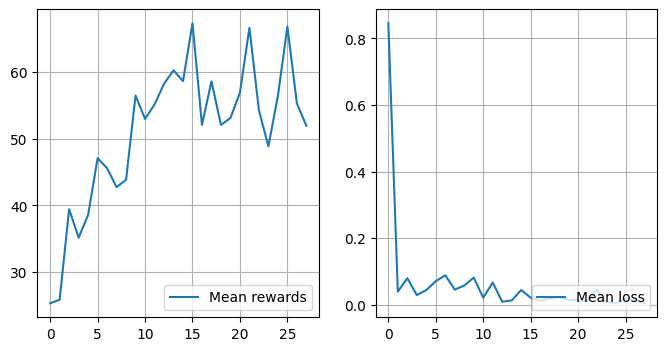

KeyboardInterrupt: 

In [32]:
log_reward = []
log_loss = []

for i in range(train_iters):
    info = [generate_session_and_train(env, network, epsilon=epsilon, train=True, gamma=gamma) for _ in range(100)]
    mean_reward = np.mean([cumul_rewards for (cumul_rewards, _) in info])
    mean_loss = np.mean([loss for (_, loss) in info][0])

    epsilon *= epsilon_rate
    assert epsilon >= 1e-4, "убедитесь, что epsilon не становится < 0"
    show_progress([mean_reward], log=log_reward, loss_batch=[mean_loss], log_loss=log_loss)

    if np.mean([cumul_rewards for (cumul_rewards, _) in info]) > 300:
        print("Принято!")
        break

### Интерпретация результатов:

Добро пожаловать в мир глубокого обучения с подкреплением! Не ждите, что вознаграждение агента будет увеличиваться плавно. Может быть оно начнет расти, если сочтет ваш код достойным :)

А если серьезно,
* __mean reward__ $-$ это среднее вознаграждение за игру. При правильной реализации оно может оставаться низким в течение первых 10 эпох, а затем начнет расти, и сойдется к ~50-100 эпохе, в зависимости от архитектуры сети.
* Если со сходимость возникли проблемы $-$ попробуйте увеличить количество скрытых нейронов или обратите внимание на эпсилон.
* __epsilon__ $-$ agent's willingness to explore. Если вы видите, что эпислон находится на уровне <0.01, до того, как агент достиг вознаграждения >= 200, установите первоначальное значение 0.1 - 0.5.

### Посмотрим на результаты:

Подключаем визуализацию:

In [33]:
try:
    import colab
    COLAB = True
except ModuleNotFoundError:
    COLAB = False
    pass

if COLAB:
    !wget https://gist.githubusercontent.com/Tviskaron/4d35eabce2e057dd2ea49a00b00aaa41/raw/f1e25fc6ac6d8f11cb585559ce8b2ab9ffefd67b/colab_render.sh -O colab_render.sh -q
    !sh colab_render.sh
    !wget https://gist.githubusercontent.com/Tviskaron/d91decc1ca5f1b09af2f9f080011a925/raw/0d3474f65b4aea533996ee00edf99a37e4da5561/colab_render.py -O colab_render.py -q
    import colab_render

In [34]:
# библиотеки и функции, которые потребуеются для показа видео
import glob
import io
import base64
from IPython import display as ipythondisplay
from IPython.display import HTML
import matplotlib.pyplot as plt
import gym

%matplotlib inline
def show_video(folder="./video"):
    mp4list = glob.glob(folder + '/*.mp4')
    if len(mp4list) > 0:
        mp4 = sorted(mp4list, key=lambda x: x[-15:], reverse=True)[0]
        video = io.open(mp4, 'r+b').read()
        encoded = base64.b64encode(video)
        ipythondisplay.display(HTML(data='''<video alt="test" autoplay
                loop controls style="height: 400px;">
                <source src="data:video/mp4;base64,{0}" type="video/mp4" />
             </video>'''.format(encoded.decode('ascii'))))
    else:
        print("Could not find video")

In [36]:
env = gym.make("CartPole-v0")
env = gym.wrappers.Monitor(env, "./video", force=True)

generate_session_and_train(env, network, epsilon=0, train=False)

env.close()
show_video()

/usr/local/lib/python3.12/dist-packages/gym/envs/registration.py:505: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1` with the environment ID `CartPole-v1`.
  logger.warn(


### Доп задание: Обучение Q learning + NN на Acrobot-v1

In [ ]:
!pip install gymnasium

In [ ]:
import gymnasium
env = gymnasium.make('Acrobot-v1', render_mode="rgb_array")


####### Здесь ваш код ########

# new_network = nn.Sequential( ....
# def generate_session_and_train(env, network, t_max=1000, epsilon=0, train=False, gamma=0.99):
#     """
#         обновленная generate_session_and_train учитывающая gymnasium интерфейс:
#                 state, info = env.reset()
#                 next_state, reward, done, truncated, info = env.reset(a)
#     ""'
#
#
# функция для обучения
